# **Segmentacao de Clientes**

### Contexto
A segmentacao de clientes e uma estrategia essencial para empresas que desejam compreender melhor o perfil e o comportamento dos consumidores. Caracteristicas como idade, renda anual, genero e padrao de gastos variam entre grupos e refletem necessidades diferentes. Identificar esses grupos permite criar campanhas mais direcionadas e aumentar a eficiencia das estrategias comerciais.

### Objetivo Geral
Aplicar a tecnica de clusterizacao K-means para segmentar clientes com base em caracteristicas demograficas e comportamentais, utilizando dados de 200 clientes.

### Objetivos Complementares
- **Pre-processamento pt-1:** verificar tipos das variaveis, limpar os dados e excluir registros com informacoes faltantes.
- **Analise exploratoria e descritiva:** identificar possiveis agrupamentos por caracteristicas demograficas e de consumo.
- **Pre-processamento pt-2:** padronizar os dados para garantir comparabilidade entre variaveis e apoiar a modelagem.
- **Modelagem:** aplicar o algoritmo K-means, definindo o numero de clusters de acordo com os achados da analise.
- **Avaliacao:** analisar centroides, dispersao e coerencia dos grupos formados.

### Base de Dados
A base possui 200 registros com as seguintes features (Tabela 1).

| Features                | Tipo   | Nulos | Minimo | Maximo |
|:------------------------|:-------|------:|:-------|:-------|
| CustomerID              | int64  |     0 | 1      | 200    |
| Gender                  | object |     0 | Female | Male   |
| Age                     | int64  |     0 | 18     | 70     |
| Annual Income (k$)      | int64  |     0 | 15     | 137    |
| Spending Score (1-100)  | int64  |     0 | 1      | 99     |

**Tabela 1**

## **1. Importação de Bibliotecas & dataload**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

cores = ['dodgerblue', 'tomato', 'blueviolet', 'darkorange', 'forestgreen', 'crimson']
sns.set_palette(cores)


def annotate_bars(ax, fmt="{:.1f}", suffix=""):
    """Anota o valor no topo de cada barra de um eixo."""
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            f"{fmt.format(height)}{suffix}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
        )


def plot_cluster_metric_bar(ax, data, y_col, title, ylabel, cluster_order):
    """Cria barplot por cluster e genero com anotacoes."""
    sns.barplot(
        data=data,
        x="cluster",
        y=y_col,
        hue="Gender",
        order=cluster_order,
        edgecolor='None',
        errorbar=None,
        ax=ax
    )
    ax.set_title(title, pad=12)
    ax.set_ylabel(ylabel)
    annotate_bars(ax)


def run_shapiro_tests(dataframe, columns):
    """Executa e imprime teste de normalidade de Shapiro-Wilk para colunas numericas."""
    print("======= Teste de Normalidade Shapiro-Wilk =====")
    for col in columns:
        stat, p_val = shapiro(dataframe[col])
        print(f"Shapiro-Wilk ({col}): p={p_val:.3f}")
        if p_val < 0.05:
            print("Distribuicao NAO e normal.")
        else:
            print("Distribuicao PODE ser normal.")


def plot_scatter_with_centroids(ax, data, x_col, y_col, centers, title, hue_order=None, show_legend=True):
    """Cria scatter por cluster e destaca centroides."""
    sns.scatterplot(
        data=data,
        x=x_col,
        y=y_col,
        hue='cluster',
        hue_order=hue_order,
        legend=show_legend,
        alpha=0.5,
        s=100,
        ax=ax
    )
    x_idx = data.columns.get_loc(x_col)
    y_idx = data.columns.get_loc(y_col)
    ax.scatter(
        centers[:, x_idx],
        centers[:, y_idx],
        marker='*',
        s=100,
        linewidths=2,
        label='Centroides'
    )
    ax.set_title(title)


# Leitura dos dados
df = pd.read_csv('../../Base de Dados/Mall_Customers.csv')
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## **2. Pré-processamento: Tipos e limpeza de dados**

In [2]:
# remover coluna CustomerID: Não carrega significado sobre o comportamento ou perfil do cliente.( não é previsível)
df.drop('CustomerID',axis=1,inplace=True)

#renomear colunas para melhor manipulação:
df.rename(columns={'Annual Income (k$)': 'annual_income'}, inplace=True)
df.rename(columns={'Spending Score (1-100)': 'score'}, inplace=True)

#renomear variavael categorica
#df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

resume=pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Mínimo': df.min(),
    'Máximo': df.max()      
})
print(resume)

                 Tipo  Nulos  Mínimo Máximo
Gender         object      0  Female   Male
Age             int64      0      18     70
annual_income   int64      0      15    137
score           int64      0       1     99


**Nota:** nao ha valores nulos no conjunto de dados.

## **3. Análise exploratória e descritiva**


 Estatísticas descritivas:


,Age,annual_income,score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


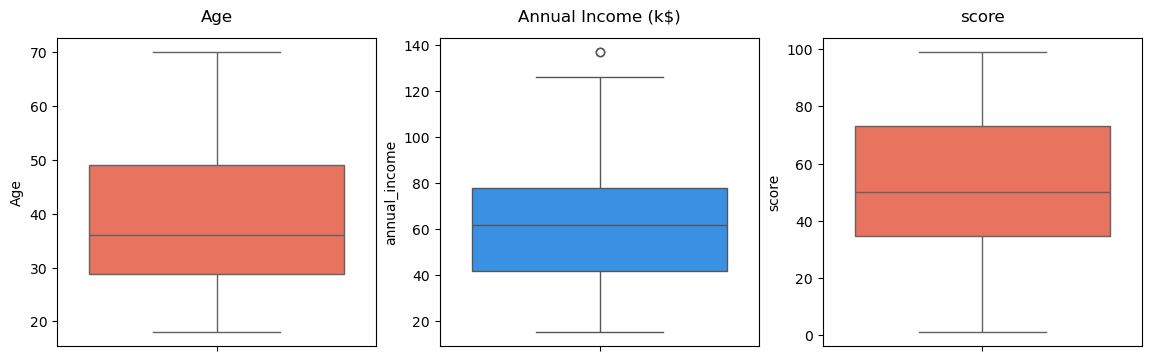

In [3]:
# Estatísticas descritivas
print("\n Estatísticas descritivas:")
display(df.describe())

fig, axs = plt.subplots(1,3, figsize=(14, 4))

sns.boxplot(data=df['Age'],color='tomato',ax=axs[ 0])
axs[0].set_title("Age", pad=12)

sns.boxplot(data=df['annual_income'],color='dodgerblue',ax=axs[ 1])
axs[ 1].set_title("Annual Income (k$)", pad=12)

sns.boxplot(data=df['score'], orient='v',color='tomato',ax=axs[ 2])
axs[ 2].set_title("score", pad=12)
plt.show()

**Consideracao parcial:** nao foram observados outliers relevantes nas features numericas.

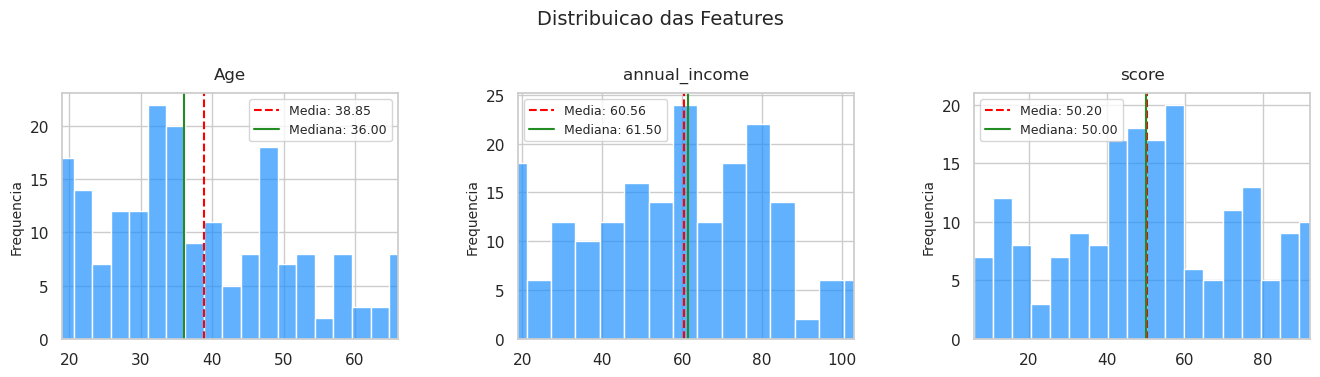

======= Teste de Normalidade Shapiro-Wilk =====
Shapiro-Wilk (Age): p=0.000
Distribuicao NAO e normal.
Shapiro-Wilk (annual_income): p=0.004
Distribuicao NAO e normal.
Shapiro-Wilk (score): p=0.000
Distribuicao NAO e normal.


In [4]:
sns.set(style="whitegrid")
colunas = list(df.select_dtypes(include='number').columns)
bins_var = [20, 20, 20]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, coluna in enumerate(colunas):
    sns.histplot(df[coluna], color='dodgerblue', bins=bins_var[i], alpha=0.7, ax=axes[i])
    axes[i].axvline(
        df[coluna].mean(),
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f"Media: {df[coluna].mean():.2f}"
    )
    axes[i].axvline(
        df[coluna].median(),
        color='forestgreen',
        linestyle='-',
        linewidth=1.5,
        label=f"Mediana: {df[coluna].median():.2f}"
    )
    axes[i].set_title(coluna, fontsize=12, pad=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequencia", fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(df[coluna].quantile(0.05), df[coluna].quantile(0.95))

plt.tight_layout(pad=3.0)
plt.suptitle('Distribuicao das Features', y=1.02, fontsize=14)
plt.show()

run_shapiro_tests(df, colunas)

**Considerações parciais:** Distribuição não é normal (Teste shapiro-wilk de normalidade(anexo). Assimetrias são observadas em todas as >distribuições, com algumas prevalências para jovens adultos  (30-36 anos), renda entre 45- 82k e score entre 45-60.


/tmp/ipykernel_100500/1405968122.py:10: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.barplot(data=df_bar, x='Genero', y='Porcentagem', palette=cores, edgecolor='None')


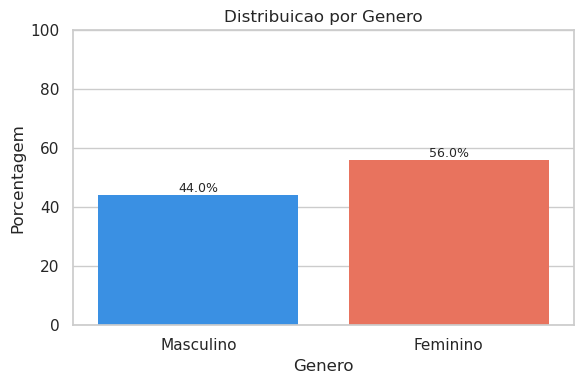

In [5]:
sns.set(palette=cores, style="whitegrid")

p1 = df['Gender'].value_counts(normalize=True) * 100
df_bar = pd.DataFrame({
    'Genero': ['Masculino', 'Feminino'],
    'Porcentagem': [p1[1], p1[0]]
    })

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df_bar, x='Genero', y='Porcentagem', palette=cores, edgecolor='None')

plt.title('Distribuicao por Genero')
plt.ylim(0, 100)
annotate_bars(ax, suffix="%")

plt.tight_layout()
plt.show()

**Considerações parciais:** O gênero feminino é ligeiramente superior (56%) na base de dados de clientes.

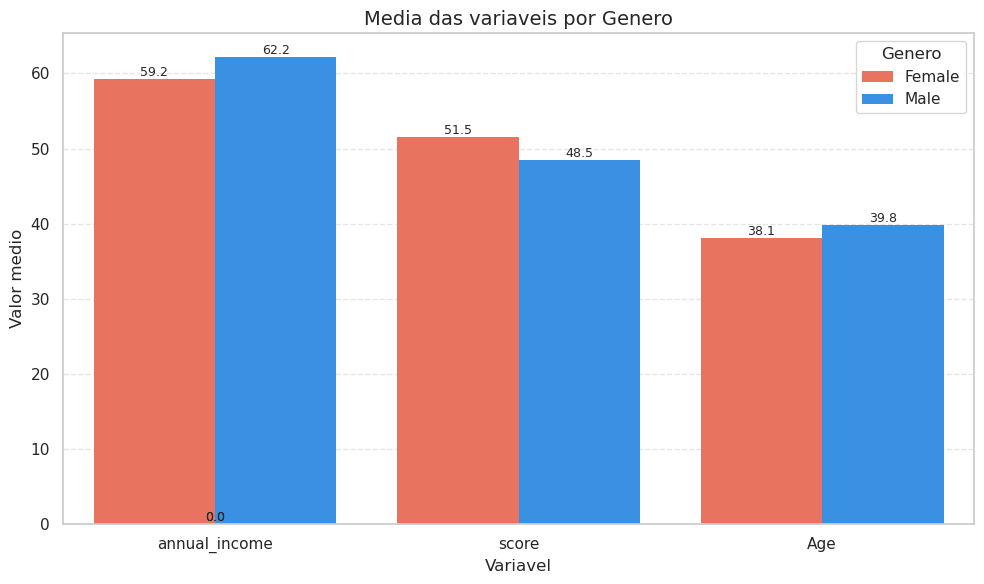

In [6]:
# agrupamento para comparar generos
dfg = df.copy()
means = dfg.groupby("Gender")[["annual_income", "score", "Age"]].mean().reset_index()

means_melted = means.melt(
    id_vars="Gender",
    value_vars=["annual_income", "score", "Age"],
    var_name="Variavel",
    value_name="Media"
    )

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=means_melted,
    x="Variavel",
    y="Media",
    hue="Gender",
    palette=['tomato', 'dodgerblue'],
    edgecolor='None'
    )

plt.title("Media das variaveis por Genero", fontsize=14)
plt.ylabel("Valor medio")
plt.xlabel("Variavel")
plt.legend(title="Genero")
plt.grid(axis="y", linestyle="--", alpha=0.5)
annotate_bars(ax)

plt.tight_layout()
plt.show()

**Considerações parciais**: A distribuição da features baseada nos gênero, mostra que as diferenças são pequenas. Em média:
* Homens têm renda ligeiramente maior(5%);
* Mulheres tem um consumo ligeiramente maior(6%);
* Homens são ligeiramente mais velhos(4%);

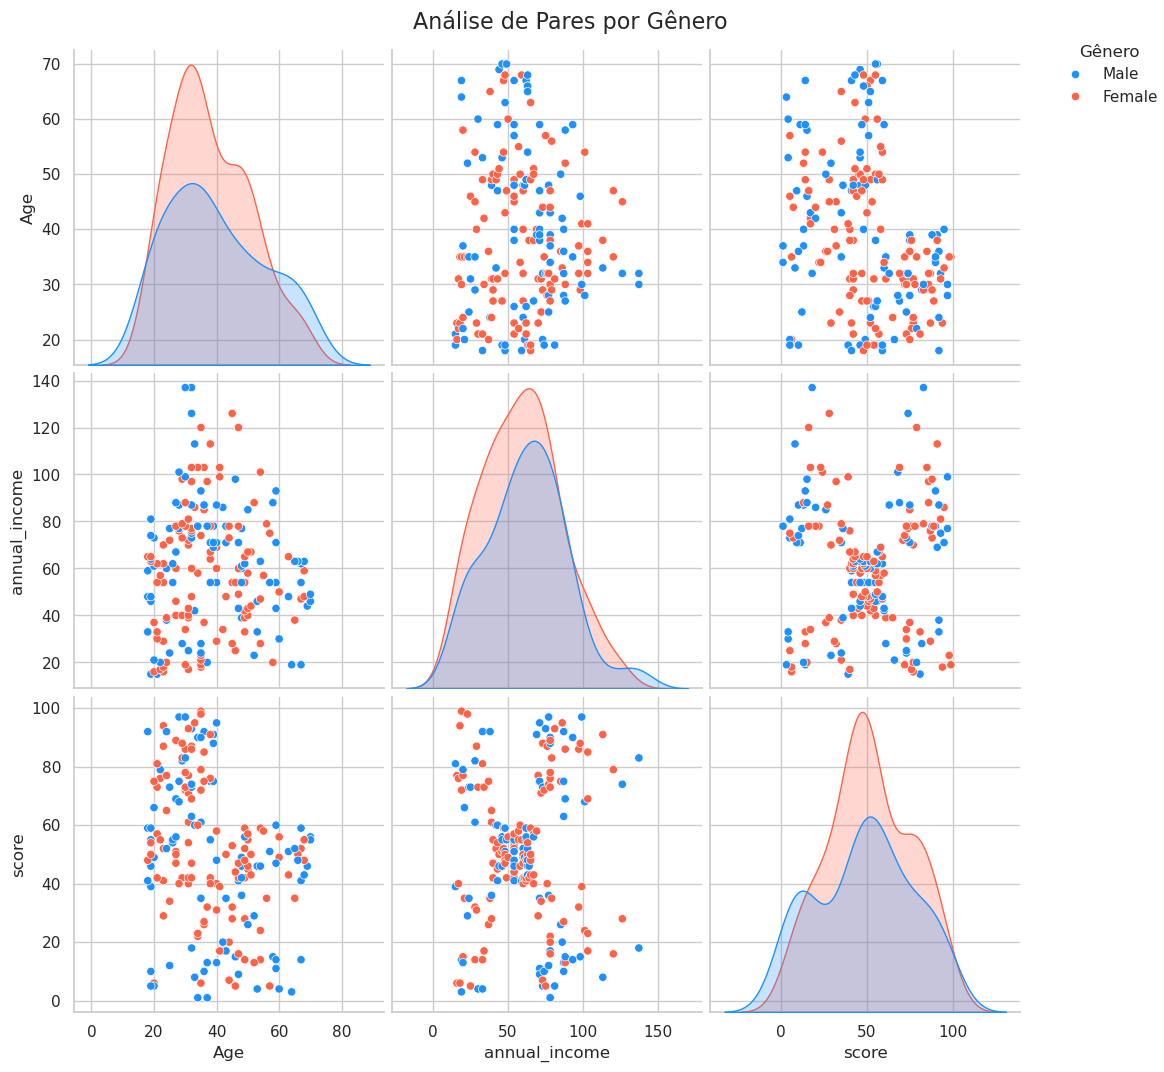

In [7]:
#Pairplot
p=sns.pairplot(df, hue="Gender",height=3.5, diag_kind="kde")
p.fig.suptitle("Análise de Pares por Gênero", fontsize=16, y=1.02)

p._legend.set_bbox_to_anchor((1.01, 0.95))
p._legend.set_title("Gênero")

plt.show();

**Considerações parciais:**

* **Idade x renda :** Não há uma correlação clara,portanto jovens e idosas podem ter tanto rendas baixas quanto altas.
* **Idade x Score :** sugerem diferentes padrões de consumo entre jovem e pessoas mais velhas. Não observamos score alto (>60) em pessoas acima de
~40

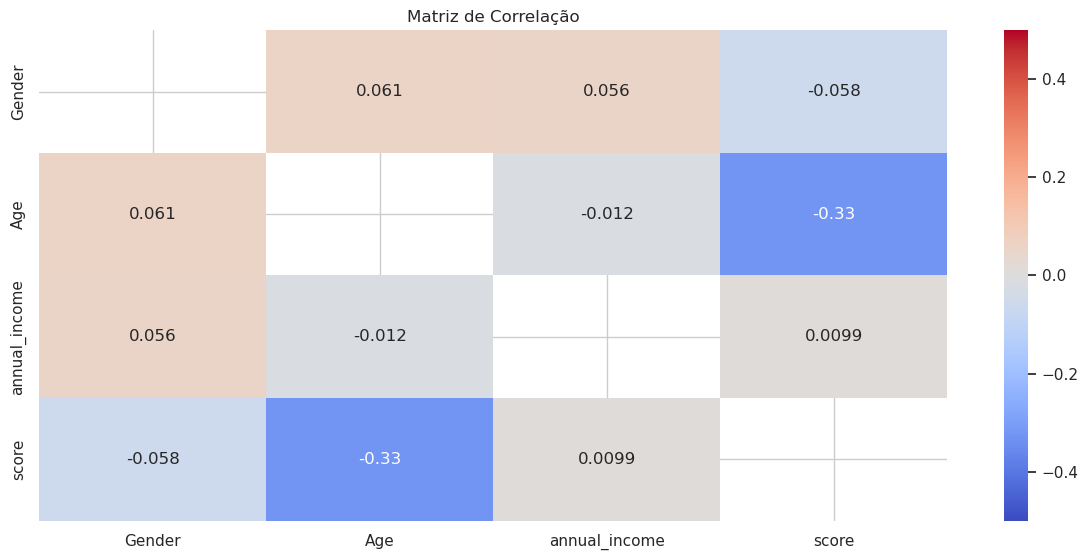

In [8]:
# Matriz de Correlação
dfn=df.copy() # dfn cópia de df atribuição binaria 0/1 para gênero 
dfn['Gender'] = dfn['Gender'].map({'Female': 0, 'Male': 1})
cm = dfn.corr()
cm[cm >=0.99] = pd.NA
#cm[(cm < 0.3)&(cm > -0.3)] = pd.NA
plt.figure(figsize=(12, 6))
sns.heatmap(cm,annot=True, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout(rect=[0.0, 0, 1, 0.96])

plt.show()

#colunas = list(df.select_dtypes(include='number').columns)

**Considerações parciais:**
Apenas a correlação entre **Age** e **Score** mostram uma correlação negativa significativa(-0.33). Pessoas mais jovem tendem a ter um score maior.

## **4. Pré-Modelagem K-Means**

In [9]:
# Pré-modelagem

# Inicializar o StandardScaler
scaler = StandardScaler()     # Inicializar o StandardScaler
# Seleção de colunas numéricas
X = dfn[colunas]               
# Ajustar e transformar os dados selecionados
X_scaled= scaler.fit_transform(X)

#### 4.1 Análise PCA

O PCA mostra se há padrões relevantes de separação entre gêneros usando apenas variáveis numéricas. Se não houver distinção clara entre os gêneros após o PCA, incluir "gender" no K-Means não é necessário. Assim, é possível justificar a exclusão de gênero do processo de clusterização.

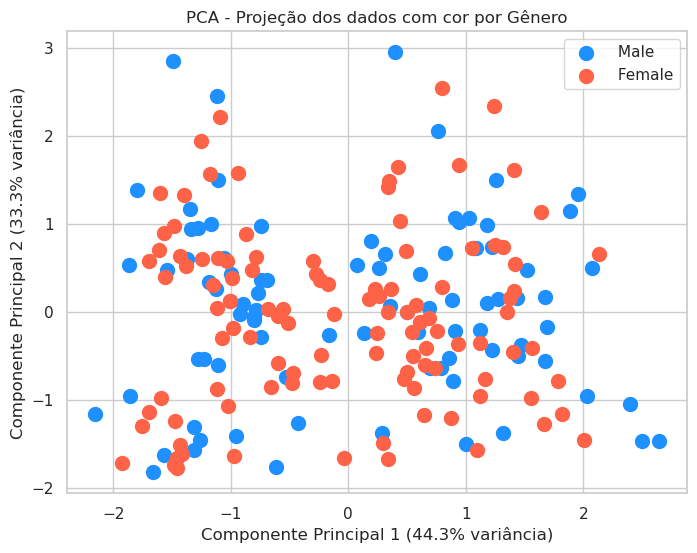

In [10]:
# Análise PCA
from sklearn.decomposition import PCA

# Aplicação do PCA para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_

sns.set(palette=cores,style="whitegrid")
# Gráfico da projeção PCA colorido por gênero
plt.figure(figsize=(8, 6))
for gender in df['Gender'].unique():
    plt.scatter(X_pca[df['Gender'] == gender, 0],
                X_pca[df['Gender'] == gender, 1],
                label=f' {gender}', s=100)
plt.title('PCA - Projeção dos dados com cor por Gênero')
plt.xlabel(f'Componente Principal 1 ({explained_var[0]*100:.1f}% variância)')
plt.ylabel(f'Componente Principal 2 ({explained_var[1]*100:.1f}% variância)')
plt.legend()
plt.grid(True)
plt.show()

**Comentarios:**
A PCA foi aplicada somente nas variaveis numericas para verificar se havia separacao natural entre generos nesse espaco. Os dois primeiros componentes explicam cerca de 77,63% da variancia total (PC1: 44,3% e PC2: 33,33%), o que e suficiente para uma boa visualizacao dos padroes principais.

No grafico, os pontos de genero nao formam grupos claramente separados. Isso indica que o genero nao deve ser a variavel principal para formar os clusters neste problema. Assim, a clusterizacao inicial foi conduzida apenas com variaveis numericas, deixando o genero para a etapa de interpretacao dos perfis.

#### 4.2 Definicao do numero de clusters
Aplicamos quatro tecnicas para escolher o valor de K:
- **Inercia:** buscar o ponto de cotovelo.
- **Silhouette:** maior valor indica melhor separacao.
- **Calinski-Harabasz (CH):** maior valor indica maior densidade e separacao.
- **Davies-Bouldin (DB):** menor valor indica menor similaridade entre clusters.

**Objetivo:** encontrar um K que equilibre separacao e compacidade dos grupos.

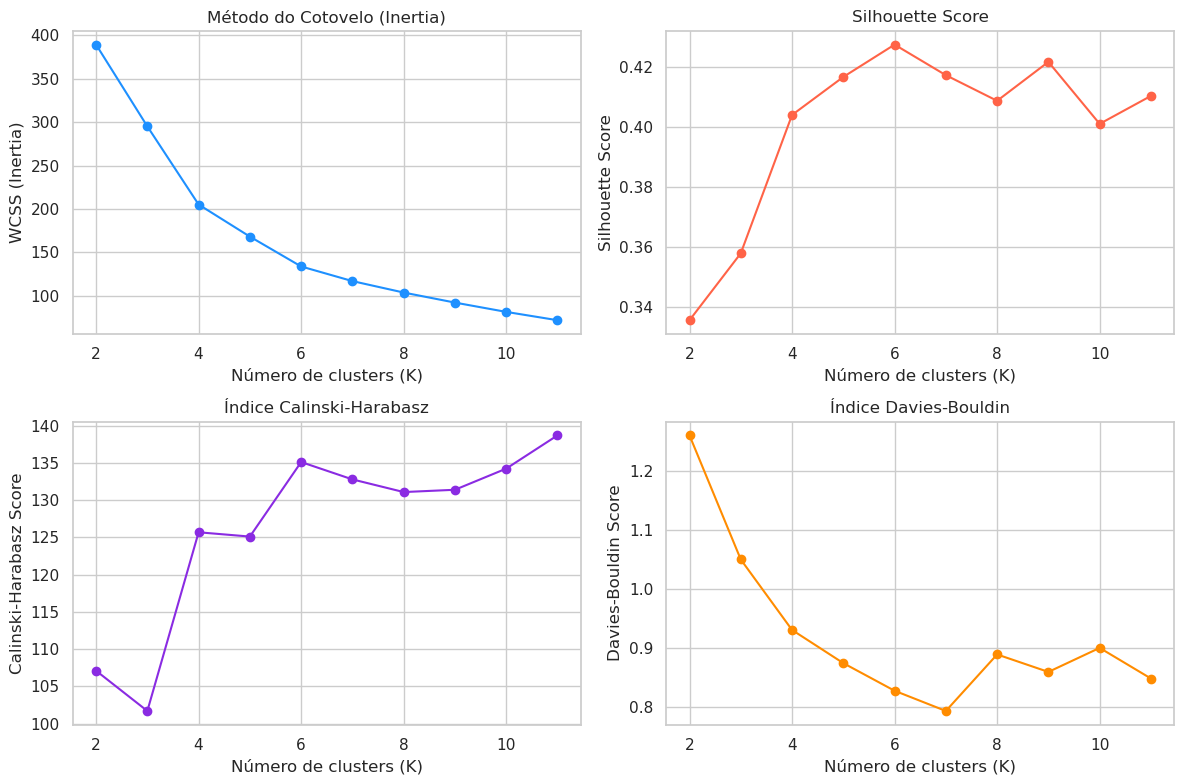

|       K |   Inertia |   Silhouette |   CH_Score |   DB_Score |
|--------:|----------:|-------------:|-----------:|-----------:|
|  2.0000 |  389.3862 |       0.3355 |   107.0956 |     1.2607 |
|  3.0000 |  295.2122 |       0.3578 |   101.6949 |     1.0503 |
|  4.0000 |  205.2251 |       0.4040 |   125.6764 |     0.9308 |
|  5.0000 |  168.2476 |       0.4166 |   125.1009 |     0.8746 |
|  6.0000 |  133.8683 |       0.4274 |   135.1022 |     0.8277 |
|  7.0000 |  117.0116 |       0.4172 |   132.7743 |     0.7935 |
|  8.0000 |  103.8286 |       0.4087 |   131.0744 |     0.8893 |
|  9.0000 |   92.2665 |       0.4217 |   131.3818 |     0.8596 |
| 10.0000 |   81.5458 |       0.4010 |   134.2209 |     0.9004 |
| 11.0000 |   71.9617 |       0.4103 |   138.6838 |     0.8485 |


In [11]:
# Número de cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Intervalo de valores de K
K_range = range(2, 12)

# Listas para armazenar as métricas
inertia = []
silhouette_scores = []
ch_scores = []
db_scores = []

# Loop para cada valor de K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Configuração do subplot 2x2
plt.figure(figsize=(12, 8))

# Subplot 1: Inertia (WCSS)
plt.subplot(2, 2, 1)
plt.plot(K_range, inertia, marker='o', color=cores[0])
plt.title('Método do Cotovelo (Inertia)')
plt.xlabel('Número de clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

# Subplot 2: Silhouette Score
plt.subplot(2, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color=cores[1])
plt.title('Silhouette Score')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Subplot 3: Calinski-Harabasz Score
plt.subplot(2, 2, 3)
plt.plot(K_range, ch_scores, marker='o', color=cores[2])
plt.title('Índice Calinski-Harabasz')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Calinski-Harabasz Score')
plt.grid(True)

# Subplot 4: Davies-Bouldin Score
plt.subplot(2, 2, 4)
plt.plot(K_range, db_scores, marker='o', color=cores[3])
plt.title('Índice Davies-Bouldin')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Davies-Bouldin Score')
plt.grid(True)

# Ajusta layout e mostra o gráfico
plt.tight_layout()
plt.show()
    

metrics_K = pd.DataFrame({
    'K': K_range,
    'Inertia': inertia,
    'Silhouette': silhouette_scores,
    'CH_Score': ch_scores,
    'DB_Score': db_scores
})

# Print as Markdown table
print(metrics_K.to_markdown(index=False, floatfmt=".4f"))

**Tendencias observadas:**
- **Inercia:** queda forte ate K=6/K=7 e desaceleracao apos esse ponto.
- **Silhouette:** pico em K=6 (0,4274).
- **Calinski-Harabasz:** pico em K=6 (aprox. 135).
- **Davies-Bouldin:** menor valor em K=7 (0,79), com K=6 muito proximo (0,82).

Dessa forma, **K=6** foi adotado como ponto de equilibrio entre as metricas. Dependendo da interpretacao de negocio e da visualizacao, K menor tambem pode ser considerado em analises futuras.

## **5. Modelagem K-means**
O modelo K-means foi configurado com tres parametros principais:
- **n_clusters = 6:** valor escolhido com base nas metricas de validacao (cotovelo, silhueta, CH e DB).
- **n_init = 100:** executa multiplas inicializacoes para reduzir risco de solucao subotima.
- **random_state = 42:** garante reprodutibilidade dos resultados.

In [12]:
# modelagem K-means
# X_scaled é o dataset normalizado, sem variavel categórica, definido na pré-modelagem
K = 6
kmeans_clients = KMeans(n_clusters=K,n_init=100,random_state=42 )
kmeans_clients.fit(X_scaled)

# Centroides
centroides = kmeans_clients.cluster_centers_

# Centroides padronizados retornados pelo k-means
centroides_padronizados = kmeans_clients.cluster_centers_  
labels = kmeans_clients.labels_

# Inverter a padronização para obter os centroides originais
centroides_originais = scaler.inverse_transform(centroides_padronizados)

# Criação do dataframe com clusters
df_clusters = pd.DataFrame({
    'Age': dfn['Age'],
    'annual_income': dfn['annual_income'],
    'score': dfn['score'],
    'Gender': dfn['Gender'],
    'cluster': labels.astype(str)  # Convertendo clusters para string (para cores categóricas)
})
# rename clusters
rename_cluster={0:'1',1:'2',2:'3',3:'4',4:'5',5:'6'}
df_clusters['cluster'] = kmeans_clients.labels_
df_clusters['cluster'] = df_clusters['cluster'].map(rename_cluster)

#### 5.A Pair Plot

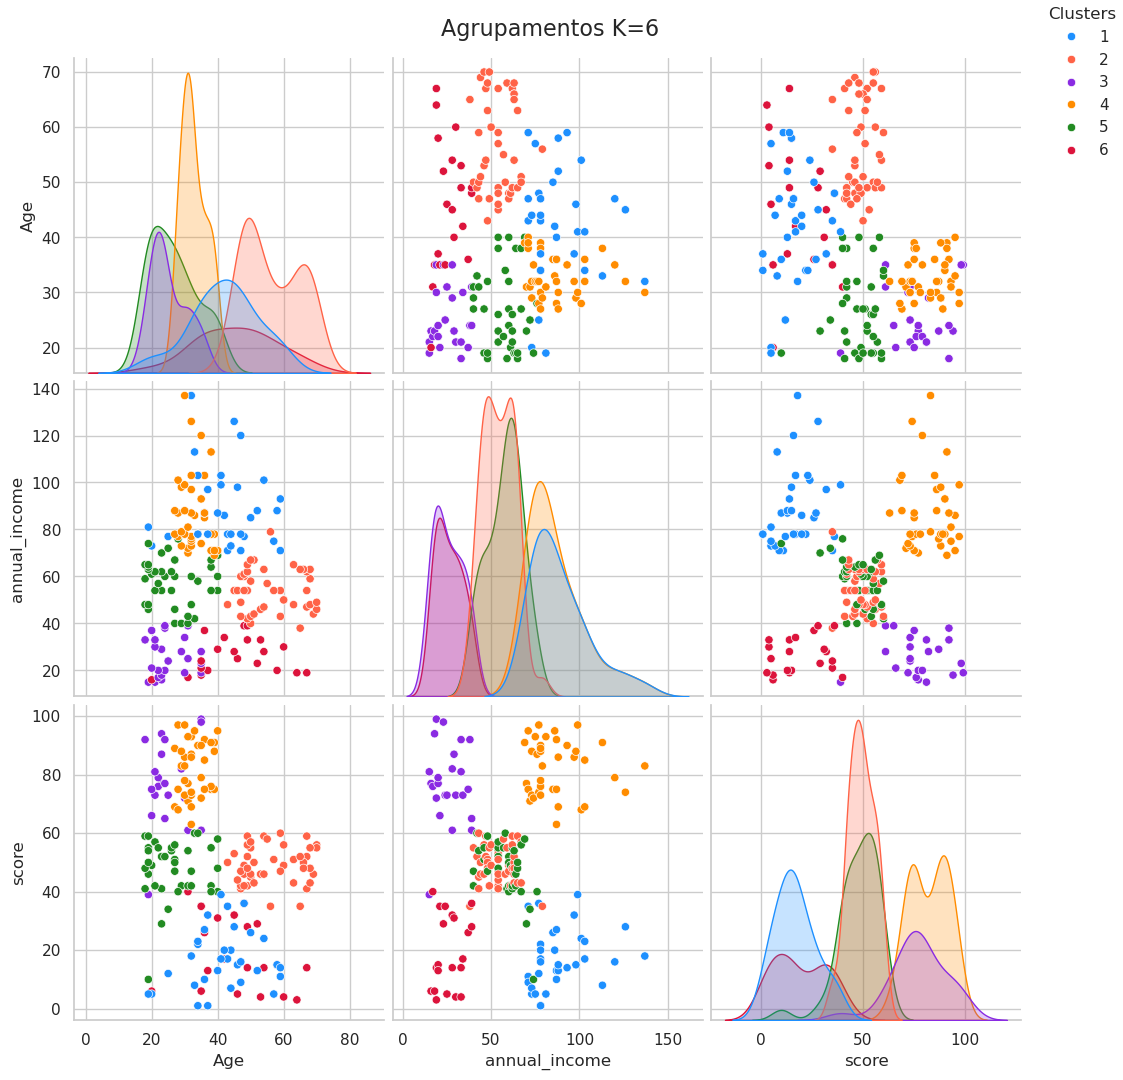

In [13]:
#pair_plot
# Garantir ordenamento dos cluster
cluster_order = sorted(df_clusters['cluster'].unique())
p=sns.pairplot(df_clusters.drop(columns=["Gender"]),height=3.5,hue='cluster',hue_order=cluster_order)
p.fig.suptitle("Agrupamentos K=6", fontsize=16, y=1.02)
p._legend.set_bbox_to_anchor((1.01, 0.95))
p._legend.set_title("Clusters")
plt.show();

#### 5.B Boxplot

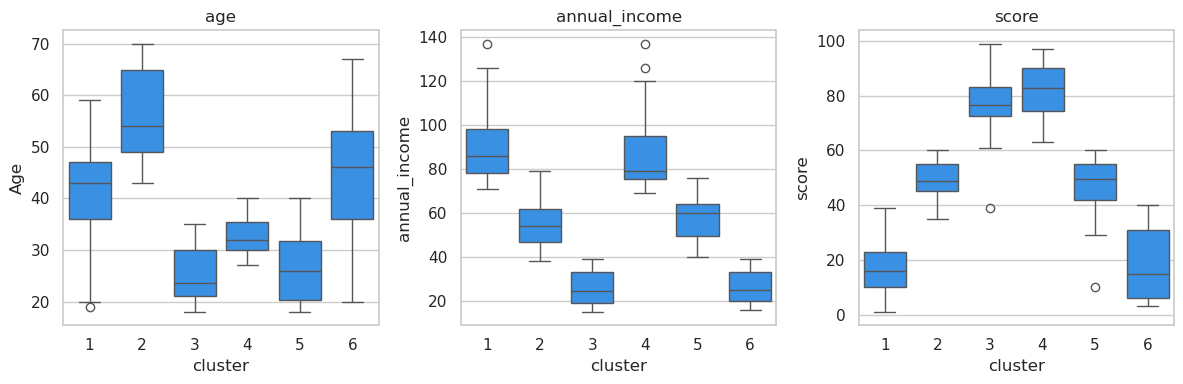

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
sns.boxplot(data=df_clusters, x='cluster', y='Age', order=cluster_order,ax=axs[0])
axs[0].set_title('age')

sns.boxplot(data=df_clusters, x='cluster', y='annual_income',order=cluster_order, ax=axs[1])
axs[1].set_title('annual_income')

sns.boxplot(data=df_clusters, x='cluster', y='score', order=cluster_order,ax=axs[2])
axs[2].set_title('score')

plt.tight_layout()
plt.show()

**Insights iniciais**:

* **Clusters 3 e 4**: Adultos jovens com alta renda e otimos score. Oportunidade para novas ofertas. Jovens com baixa renda também apresentam otímo score porém com menor poder de compra. 
* **Cluster 5**: Público jovem intermediário,possivelmente em inicio de construção de carreira, pode evoluir para perfis mais valiosos com ações adequadas de retenção e desenvolvimento.
* **Clusters 1 e 2**: clientes mais velhos, especialmente 0 com alta renda, mas score baixo. Menos engajados ou cautelosos nas financas. Espaço para buscar entender as necessidades desse perfil com renda alta.  
* **Cluster 6 :** Adultos com limitações financeiras e score baixo, importante para ofertas de crédito responsável ou produtos de entrada.

**Tabela descritiva:**

| Cluster | Idade Média | Renda Média | Score Médio ↑ | Resumo                                  |
|---------|-------------|-------------|--------------|------------------------------------------|
|   4     |    32,7     |    86,5     |     82,1     | Jovens Adultos com alta renda e score ótimo |
|   3     |    25,3     |    25,8     |     76,9     | Jovens, baixa renda, score alto          |
|   2     |    56,3     |    54,3     |     49,1     | Adultos-idoso , renda/score moderados          |
|   5     |    26,7     |    57,6     |     47,8     | Jovens, renda/score  moderados            |
|   1     |    41,9     |    88,9     |     17,0     | Adultos+40 com alta renda, score baixo     |
|   6     |    45,5     |    26,3     |     19,4     | Adultos+40 com baixa renda e score baixo       |


#### 5. C Centroides

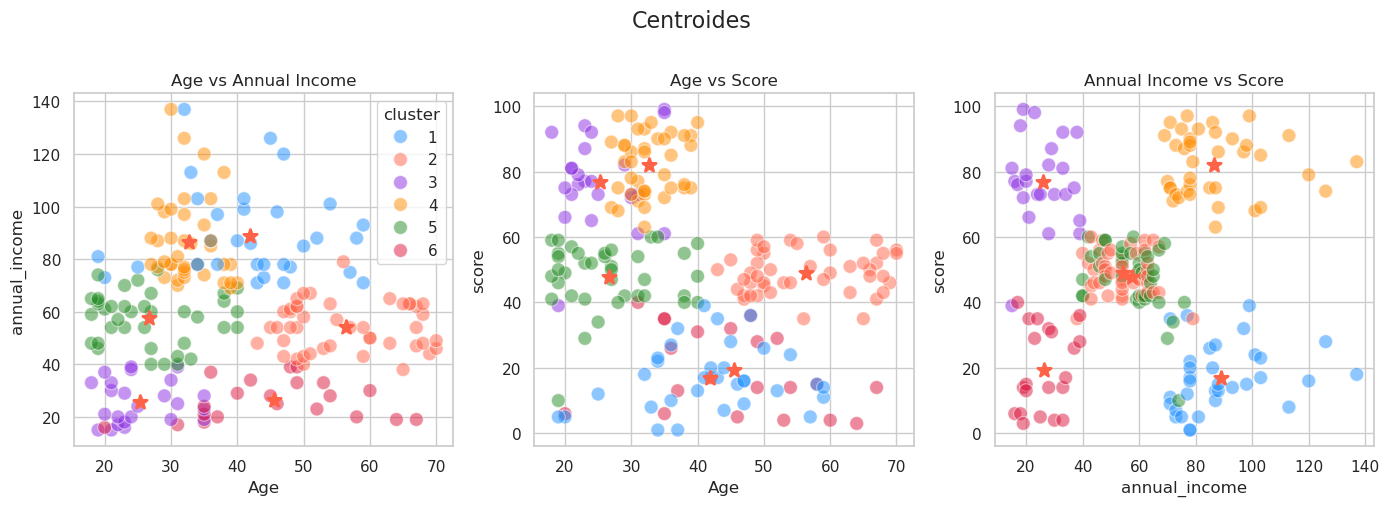

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Centroides", fontsize=16, y=1.01)

plot_scatter_with_centroids(
    ax=axes[0],
    data=df_clusters,
    x_col='Age',
    y_col='annual_income',
    centers=centroides_originais,
    title='Age vs Annual Income',
    hue_order=cluster_order,
    show_legend=True
    )

plot_scatter_with_centroids(
    ax=axes[1],
    data=df_clusters,
    x_col='Age',
    y_col='score',
    centers=centroides_originais,
    title='Age vs Score',
    hue_order=cluster_order,
    show_legend=False
    )

plot_scatter_with_centroids(
    ax=axes[2],
    data=df_clusters,
    x_col='annual_income',
    y_col='score',
    centers=centroides_originais,
    title='Annual Income vs Score',
    hue_order=cluster_order,
    show_legend=False
    )

plt.tight_layout()
plt.show()

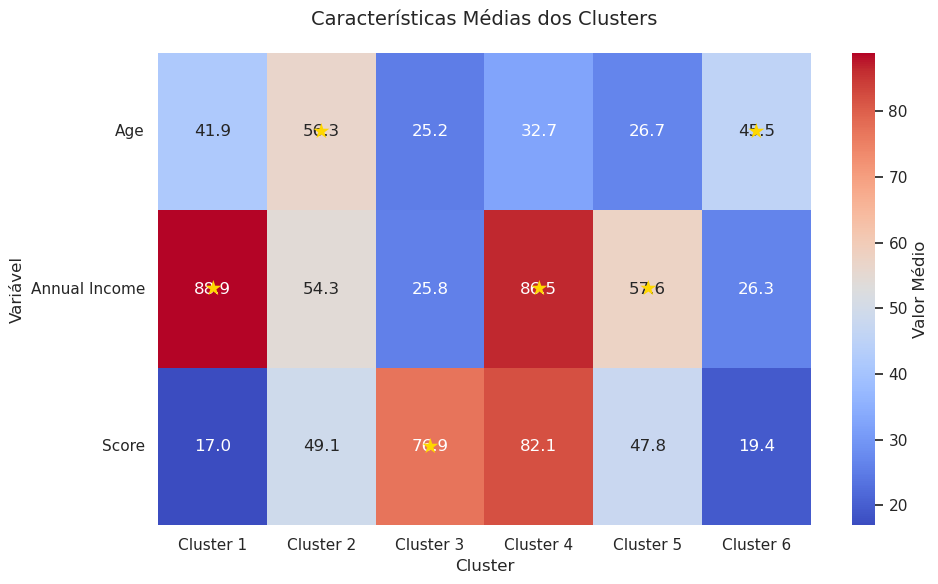

In [16]:
#Destaque de cada cluster
# Criar DataFrame
centroides_df = pd.DataFrame(centroides_originais, 
                            columns=['Age', 'Annual Income', 'Score'],
                            index=[f'Cluster {i+1}' for i in range(6)])

# Configurações do gráfico
plt.figure(figsize=(10, 6))
sns.heatmap(centroides_df.T,  # Transpor para ter features nas linhas
            annot=True, 
            fmt=".1f",cmap='coolwarm',
            cbar_kws={'label': 'Valor Médio'})

# Melhorar a visualização
plt.title("Características Médias dos Clusters", pad=20, fontsize=14)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Variável", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

# Adicionar anotações extras
for i in range(len(centroides_df)):
    max_feature = centroides_df.iloc[i].idxmax()
    plt.text(i+0.5, 
             centroides_df.columns.get_loc(max_feature)+0.5, 
             '★', 
             ha='center', 
             va='center',
             color='gold',
             fontsize=15)

plt.tight_layout()
plt.show()



**Observacoes:**
- Alta renda nao garante alto score (Cluster 1 vs Cluster 4).
- Baixa renda pode coexistir com alto score (Cluster 3).

#### 5.D Distribuicoes

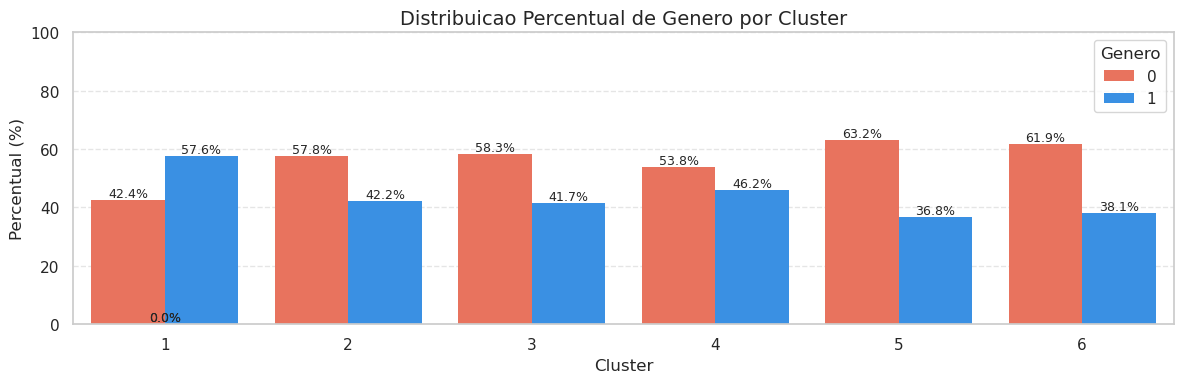

In [17]:
# Distribuicao de genero por cluster
gender_counts = df_clusters.groupby("cluster")["Gender"].value_counts().unstack(fill_value=0)
gender_percent = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100

percentuais = gender_percent.rename(columns={0: '0', 1: '1'}).reset_index()
df_genero = pd.melt(
    percentuais,
    id_vars='cluster',
    value_vars=['0', '1'],
    var_name='Gender',
    value_name='Percentual'
    )

plt.figure(figsize=(12, 4))
ax = sns.barplot(
    data=df_genero,
    x='cluster',
    y='Percentual',
    hue='Gender',
    palette=['tomato', 'dodgerblue'],
    edgecolor='None'
    )

plt.title("Distribuicao Percentual de Genero por Cluster", fontsize=14)
plt.ylabel("Percentual (%)")
plt.xlabel("Cluster")
plt.legend(title="Genero")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim(0, 100)

annotate_bars(ax, suffix="%")
plt.tight_layout()
plt.show()

**Observacoes:**
Com excecao do Cluster 1, todos os demais sao majoritariamente compostos por mulheres, algo coerente com a distribuicao geral da base.

In [18]:
#organizar grupos e clusteres 
df_clusters_0=df_clusters[df_clusters['Gender']==0]
df_clusters_1=df_clusters[df_clusters['Gender']==1]

df_age = df_clusters.groupby(['cluster', 'Gender'])['Age'].mean().reset_index()
df_income = df_clusters.groupby(['cluster', 'Gender'])['annual_income'].mean().reset_index()
df_score = df_clusters.groupby(['cluster', 'Gender'])['score'].mean().reset_index()

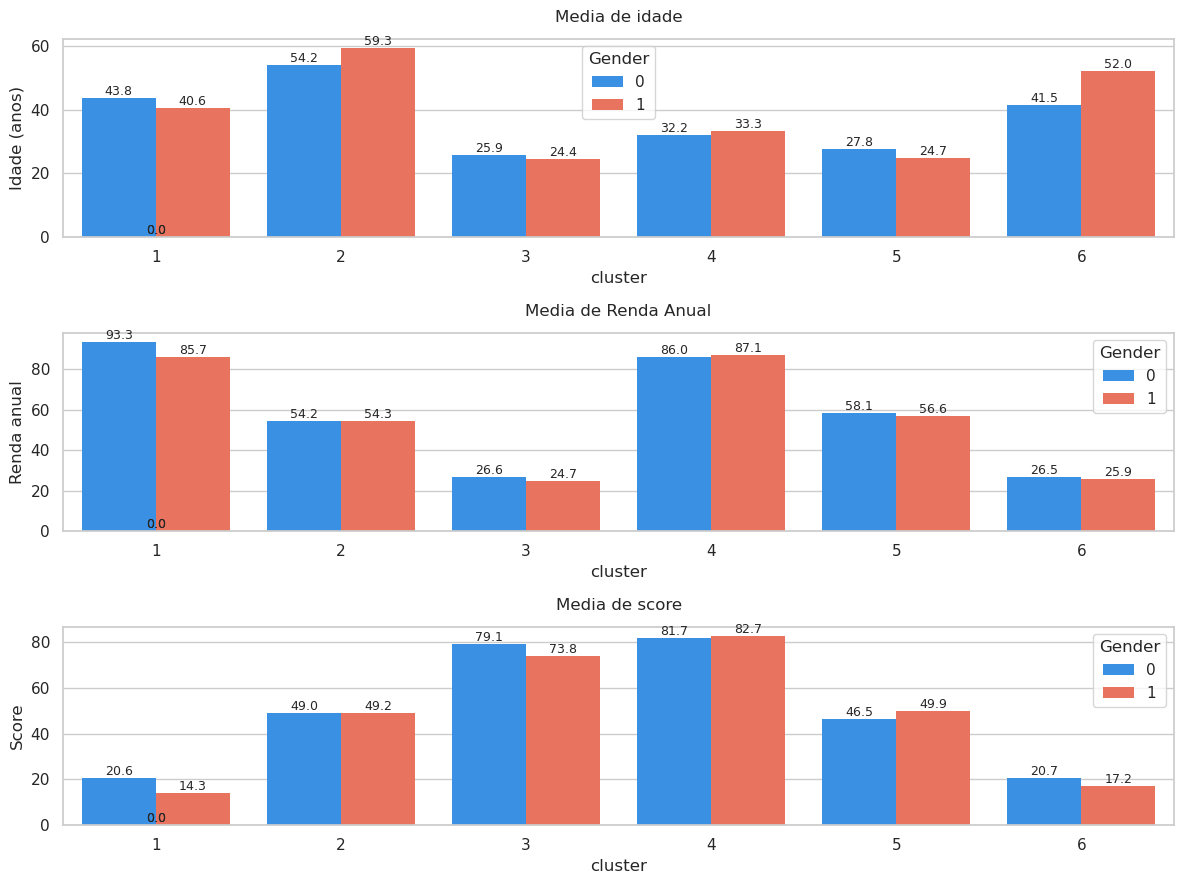

In [19]:
fig, axs = plt.subplots(3, 1, figsize=(12, 9))

plot_cluster_metric_bar(
    ax=axs[0],
    data=df_age,
    y_col='Age',
    title='Media de idade',
    ylabel='Idade (anos)',
    cluster_order=cluster_order
    )

plot_cluster_metric_bar(
    ax=axs[1],
    data=df_income,
    y_col='annual_income',
    title='Media de Renda Anual',
    ylabel='Renda anual',
    cluster_order=cluster_order
    )

plot_cluster_metric_bar(
    ax=axs[2],
    data=df_score,
    y_col='score',
    title='Media de score',
    ylabel='Score',
    cluster_order=cluster_order
    )

plt.tight_layout()
plt.show()

**Comentários:** \
De modo geral, as distribuições das variáveis por gênero dentro de cada cluster mostram padrões similares aos observados nos boxplots dos próprios clusters, sem grandes discrepâncias internas. No entanto, a análise detalhada revela pontos de destaque relevantes para interpretação dos perfis.


**Clusters com Maior Idade Média e Diferença de Gênero**

Os clusters 2 e 6 concentram as maiores médias de idade. Eles também apresentam as maiores diferenças de idade entre gêneros: 5,1 anos (cluster 2) e 10,5 anos (cluster 6). Isso sugere uma segmentação relevante por faixa etária dentro do próprio cluster, que pode indicar perfis ou fases de vida distintos entre homens e mulheres.

**Clusters com Menores Diferenças de Idade e Maiores Scores**

Clusters 3 e 4 exibem pequenas diferenças de idade entre gêneros e, ao mesmo tempo, os maiores scores médios.Essa homogeneidade etária pode contribuir para uma experiência mais similar entre os gêneros, refletindo em percepções de valor ou engajamento elevados.

**Relação Entre Renda e Score**

O cluster 1 mostra alta renda média, mas score baixo. Esse descompasso pode indicar insatisfação ou falta de engajamento, apesar do poder aquisitivo.
No sentido oposto, o cluster 3 reúne baixa renda e alto score, sugerindo um perfil de jovens que valorizam a experiência e têm alto engajamento mesmo com menor poder de compra.

**Extremos de Score por Gênero**

O menor score médio está entre os homens do cluster 1.O maior score médio é dos homens do cluster 4. A análise desses extremos pode ajudar a direcionar estratégias específicas de retenção ou fidelização para grupos de menor engajamento, e reconhecimento para aqueles com melhores indicadores.

Esses destaques reforçam que a segmentação baseada em clusterização vai além das médias globais e permite identificar nuances importantes dentro de cada grupo. Análises complementares por gênero ajudam a revelar diferenças de comportamento e potencializar estratégias de atuação personalizadas.


#### 5.E -ConvexHull

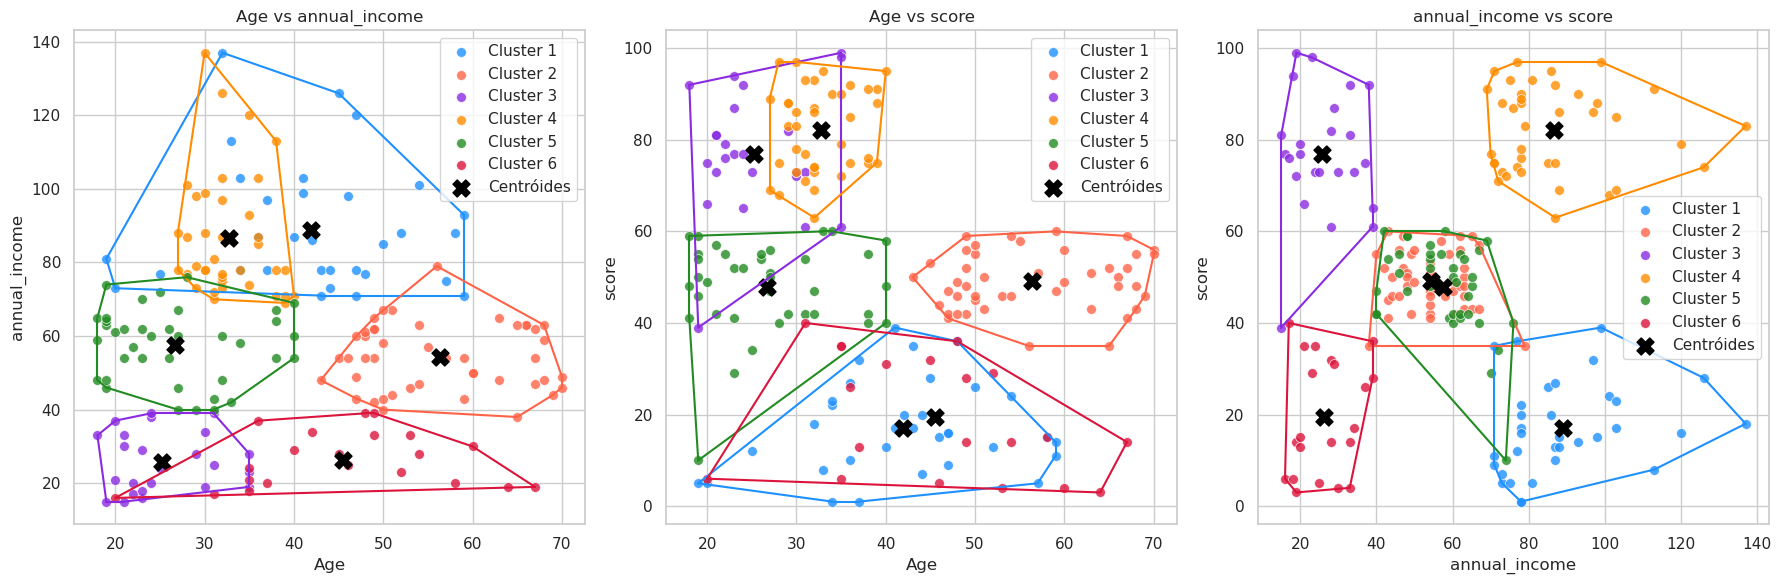

In [20]:
from scipy.spatial import ConvexHull

# Garantir que 'cluster' seja tratado como string para categorização
df_clusters['cluster'] = df_clusters['cluster'].astype(str)

# Lista dos pares de variáveis a serem plotados
var_pairs = [
    ('Age', 'annual_income'),
    ('Age', 'score'),
    ('annual_income', 'score')
]

# Cores fixas por cluster
unique_clusters = sorted(df_clusters['cluster'].unique())
#palette = sns.color_palette("tab10", n_colors=len(unique_clusters))
cores=['dodgerblue','tomato','blueviolet','darkorange','forestgreen','crimson']
sns.set_palette(cores)
cluster_color_map = {cluster: cores[i] for i, cluster in enumerate(unique_clusters)}

# Criação da figura com subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

# Iterar sobre os pares de variáveis e eixos
for ax, (x_var, y_var) in zip(axes, var_pairs):
    for cluster_id in unique_clusters:
        cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
        cor = cluster_color_map[cluster_id]

        # Pontos dos dados
        sns.scatterplot(
            x=cluster_data[x_var],
            y=cluster_data[y_var],
            color=cor,
            label=f'Cluster {cluster_id}',
            ax=ax,
            s=50,
            alpha=0.8
        )

        # Convex Hull
        if len(cluster_data) >= 5:
            points = cluster_data[[x_var, y_var]].values
            hull = ConvexHull(points)
            for simplex in hull.simplices:
                ax.plot(points[simplex, 0], points[simplex, 1], color=cor, linewidth=1.5)

    # Centróides
    x_idx = df_clusters.columns.get_loc(x_var)
    y_idx = df_clusters.columns.get_loc(y_var)
    ax.scatter(
        centroides_originais[:, x_idx],
        centroides_originais[:, y_idx],
        marker='X',
        color='black',
        s=150,
        label='Centróides'
    )

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f'{x_var} vs {y_var}')
    ax.legend()

plt.tight_layout()
plt.show()


**Comentarios:**
O grafico evidencia a regiao de influencia de cada cluster no espaco das variaveis e ajuda a avaliar sobreposicoes entre grupos.

- **Idade x Renda Anual:** o Cluster 4 (baixa dispersao em idade) aparece contido no Cluster 1 (maior variacao de idade), sugerindo potencial aglutinacao dependendo do objetivo.
- **Idade x Score:** os Clusters 1 e 6 ficam muito proximos nesse plano, indicando que a principal diferenca entre eles esta na renda anual.
- **Renda Anual x Score:** os Clusters 2 e 5 ocupam posicao mais central, com perfis intermediarios nessas variaveis.

## **6. Principais insights e comentarios**

#### 6.1 Panorama Geral dos Dados
- Diferencas por genero sao pequenas: mulheres sao 56% da base; homens tem renda media um pouco maior; mulheres apresentam score medio ligeiramente maior.
- Nao ha relacao linear clara entre idade e renda.
- A relacao idade x score e negativa: clientes mais jovens tendem a apresentar score mais alto.

#### 6.2 Perfis Centrais dos Clusters
- **Cluster 1:** alta renda e baixo score; possivel baixo engajamento apesar do poder aquisitivo.
- **Cluster 2:** clientes mais velhos, renda e score moderados; perfil mais cauteloso.
- **Cluster 3:** jovens com baixa renda e alto score; alto engajamento mesmo com menor poder de compra.
- **Cluster 4:** jovens adultos com alta renda e alto score; perfil estrategico para fidelizacao.
- **Cluster 5:** jovens com renda e score intermediarios; potencial de evolucao.
- **Cluster 6:** adultos com baixa renda e baixo score; demanda estrategias de entrada e educacao financeira.

#### 6.3 Distribuicao de Genero
Com excecao do Cluster 1, os demais clusters tem predominancia feminina, em linha com a distribuicao geral da base.

#### 6.4 Relacoes Entre Variaveis
- **Idade x Score:** relacao negativa clara.
- **Idade x Renda:** sem tendencia forte.
- **Score:** mais elevado nos clusters jovens (3, 4 e 5).

#### 6.5 Recomendacoes
- Priorizar retencao e fidelizacao para jovens com score alto.
- Investigar causas de baixo score em clientes de alta renda.
- Criar estrategias de entrada para clientes de baixa renda e baixo score.
- Usar segmentacao dinamica para acompanhar migracao de perfis ao longo do tempo.